# 3. Pytorch 컴퓨터 비전
:컴퓨터가 보는 법을 배우도록 가르치는 기술

# 우리가 다룰 내용 - pytorch 워크플로우를 컴퓨터 비전 문제에 적용
- 컴퓨터 비전 관련 내장 라이브러리들
1. 데이터 로드 - 의류 이미지 사용
2. 데이터 준비 - DataLoader 불러와 훈련 루프에서 사용할 수 있도록 준비
3. Model 0 :  베이스라인 모델 만들기 <br>
-멀티클래스 분류 모델 만들기 
-손실 함수, 옵티마이저, 훈련 루프 구성
4. Model 0 예측 및 평가
베이스라인 모델로 예측 후 결과 평가
5. 디바이스 독립 코드 설정
CPU와 GPU 어디서든 동작하는 디바이스 독립 코드 작성하는 것 <- 좋은 코딩 습관
6. Model 1: 비선형성 추가
베이스라인 모델 개선 위해 비선형 레이어(activation function 등) 추가
7. Model 2 : 합성곱 신경망(CNN)
컴퓨터 비전 특화 모델인 합성곱 신경망(Convolutional Neural Network, CNN) 소개
8. 모델 비교
지금까지 만든 세 가지 모델 비교
9. 최고의 모델 평가
무작위 이미지에 대해 예측 수행, 가장 성능이 좋은 모델 평가
10. 혼동 행렬 만들기
혼동 행렬(Confusion Matrix)은 분류 모델을 평가하는 아주 좋은 방법임
11. 최고의 모델 저장 및 불러오기
나중에 모델을 다시 사용할 수 있으므로 모델을 저장하고 제대로 다시 불러오는지 확인

# 0 ) Pytorch의 컴퓨터 비전 라이브러리
- torhvision <br>
컴퓨터 비전 문제에 자주 사용되는 데이터셋, 모델 아키텍처, 이미지 변환 기능을 포함
- torchvision.datasets <br>
이미지 분류, 객체 탐지, 이미지 캡셔닝, 비디오 분류 등 다양한 문제를 위한 예제 데이터셋을 제공.또한 사용자 정의 데이터셋을 만들 수 있는 기본 클래스 포함
- torchvision.models  <br>
Pytorch로 구현된, 성능이 좋은 대표적인 컴퓨터 비전 모델 아키텍처들이 들어 있음.
- torchvision.transforms <br>
이미지는 모델에 사용하기 전에 숫자로 변환되거나 처리(증강 등)되어야 하는 경우가 많음. 이러한 이미지 변환 함수들이 포함됨
- torch.utils.data.Dataset <br>
Pytorch 기본 데이터셋 클래스
- torch.utils.data.DataLoader <br>
Dataset 데이터셋을 Python 반복(iterable)할 수 있도록 만들어줌




In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.9.1+cu126
torchvision version: 0.24.1+cu126


# 1. 데이터셋 가져오기
컴퓨터 비전 문제 시작하기 위해 컴퓨터 비전 데이터셋 가져오기 <br>
-> 우린 FasionMNIST로 시작 <br>
MNIST(Modified Nationa Institute of Standards and Technology)<br>

FashionMNIST - 10가지 종류의 의류에 대한 흑백 이미지 포함


-> 다중 클래스 분류 문제 (multi-class classification)   

- 데이터를 다운로드할 때 다음과 같은 파라미터들을 지정 가능
1. root:str <br>
데이터를 어느 폴더에 저장할 것인지
2. train:bool <br> 
훈련 데이터(train split)를 받을지 테스트 데이터(test split)를 받을지
3. download : bool <br>
데이터를 실제로 다운로드 할지
4. transform : torch.vision.transforms <br>
데이터를 모델에 사용하기 전에 어떤 변환(전처리)를 적용할지 
5. target_transform <br>
필요하다면 정답라벨(target)에도 변환을 적용 갸능


In [2]:
# 훈련 데이터 설정
train_data = datasets.FashionMNIST(     # FasionMNIST 데이터셋 객체를 생성
                                   root="data", #데이터를 data라는 폴더에 저장
                                   train=True,  #훈련용 데이터를 가져옴
                                   download=True, # 디스크에 데이터 없으면 다운로드
                                   transform=ToTensor(), # 이미지를 텐서로 변환
                                   target_transform= None # 라벨에 변환은 적용 x
)

# 테스트 데이터 설정
test_data = datasets.FashionMNIST(
    root="data",
    train=False, # 테스트 데이터 가져오기
    download=True,
    transform=ToTensor()
    
)

In [3]:
#  첫 학습 샘플 확인
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

# 1.1 ) 컴퓨터 비전 모델의 입력과 출력 형태 (Input and output shapes)

현재 큰 텐서(이니지 데이터)를 입력으로 받고 하나의 값(라벨)을 출력으로 가는 구조 가짐

In [4]:
image.shape

torch.Size([1, 28, 28])

-> [color_channels=1, height=28, width=28] <br>
color_channels=1이라는 것<br>
👉 이 이미지가 흑백(그레이스케일) 이미지

데이터를 숫자로 인코딩 -> 그 숫자들 속에서 패턴을 찾는 모델 만들기 -> 그 패턴을 의미 있는 결과로 변환 <br>
만약 color_channels = 3이라면, <br>
이미지는 빨강(Red), 초록(Green), 파랑(Blue) 픽셀 값 가짐 <br>
->  RGB 색상 모델

- 이미 표현 방식
1. CHW - 색상 채널, 높이, 너비
2. NCHW - N : 이미지 개수(batch size)

In [5]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [6]:
# 클래스 확인
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

-> 서로 다른 10가지 의류 종류

# 1.2 ) 데이터 시각화하기

Image shape: torch.Size([1, 28, 28])


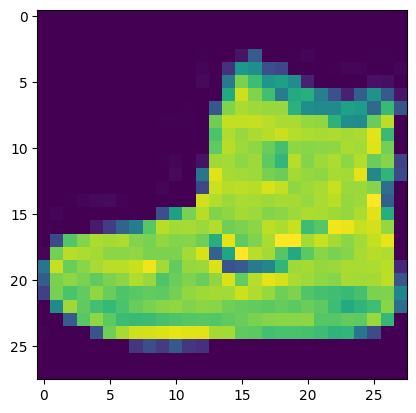

In [7]:
import matplotlib.pyplot as plt
image, label = train_data[0]    #train_data의 첫 번째 데이터 가져옴. trian_data[0]은 (이미지, 라벨)형태의 튜플 반환
plt.imshow(image.squeeze()) # image shape is [1, 28, 28] (colour channels, height, width)

print(f"Image shape: {image.shape}")

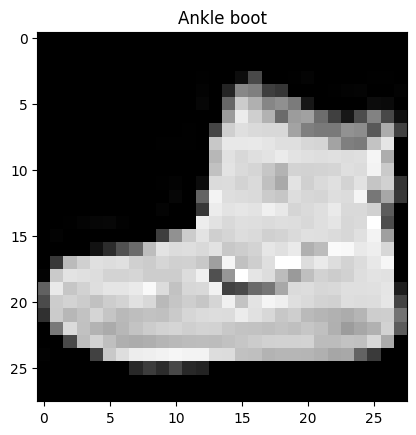

In [8]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label]);

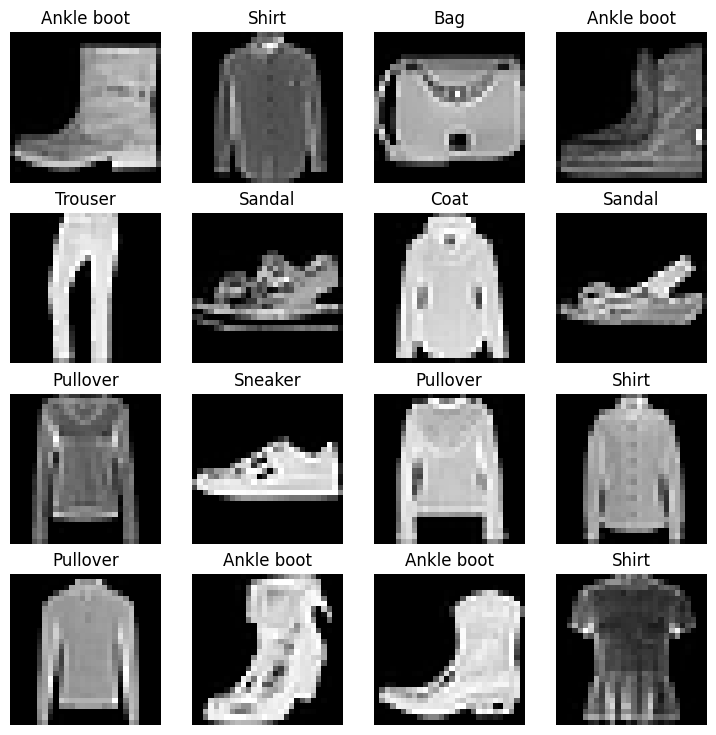

In [9]:
#plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols= 4,4 
for i in range(1, rows*cols + 1):       # 16까지 반복
    random_idx = torch.randint(0, len(train_data), size=[1]).item()     # torch.randint->랜덤 정수 생성     .item()-> 텐서 값 숫자로 변환
    img, label = train_data[random_idx] # 랜덤하게 뽑은 이미지와 그 정답 라벨 가져옴
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")  # squeeze(): 1 차원 제거 | ex. [1, 28, 28]->[28, 28]
    plt.title(class_names[label])   # 숫자 라벨 대신 옷 이름 표시
    plt.axis(False)     # x축, y축 눈금 제거

픽셀 값들을 입력으로 받아 그 안에서 패턴을 찾는 모델 만듬 -> 그 패턴을 미래의 새로운 픽셀 값들에 적용

# 2 ) DataLoader 준비
데이터셋 준비 후 -> torch.utils.data.DataLoader로 준비 <br>
- DataLoader : 데이터를 모델에 로드하는 역할 <br>
-학습 , 추론할 때 사용<br>
-큰 Dataset을 작은 덩어리로 나눈 Python iterable 객체로 만들어줌<br>
- batch / mini-batch : 데이터셋을 나눈 작은 덩어리들<br>
배치로 나누는 이유 
1. 계산 효율성 때문<br>
데이터를 여러 배치로 나누어 forward pass와 backward pass 진행<br>
2. 더 잦은 학습 기회<br>
미니배치 이용시 한 epoch 당 gradient descent가 한 번이 아니라 미니배치마다 한 번씩 수행됨 <br>
미니배치마다 가중치 업데이트 <br>
-좋은 배치 사이즈 : 32 (보통 2의 거듭제곱 값 많이 사용)

In [10]:
from torch.utils.data import DataLoader     # DataLoader 불러오기
BATCH_SIZE = 32     # 배치 크기 하이퍼파라미터 설정(한 번에 32개씩 모델에 넣음)
# 데이터셋을 반복 가능한 배치 형태로 변환
train_dataloader = DataLoader(
    train_data,     #iterable로 바꿀 dataset
    batch_size=BATCH_SIZE,       # 한 배치당 샘플 개수
    shuffle=True    # 매 epoch마다 데이터 섞기
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False #테스트 데이터는 굳이 섞을 필요 X
)
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")   # train_dataloader의 길이 출력 = 총 몇개의 배치가 있는지

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x000001B2F5173AC0>, <torch.utils.data.dataloader.DataLoader object at 0x000001B2F5173280>)
Length of train dataloader: 1875 batches of 32


In [11]:
# training dataloader 안에 무엇이 있는지 확인
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

*Dataset - 전체 데이터, 인덱스로 접근 ex. 60000개 <br>
DataLoader - 배치로 나눈 데이터, 반복문으로 접근 ex.1875개 batch

- 한 배치 안에서 랜덤 이미지 하나를 뽑아서 시각화


Image size: torch.Size([1, 28, 28])
Label: 6, label size: torch.Size([])


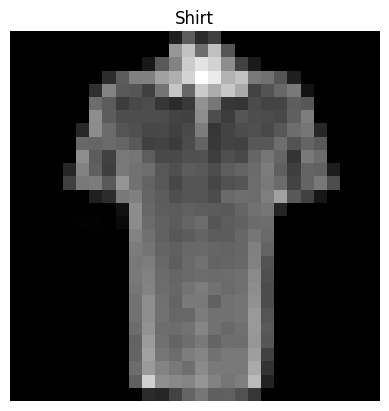

In [12]:
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()   #train_features_batch는 하나의 배치, .item()은 텐서 값을 일반 숫자로 변환
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]   # img -> 이미지 텐서 label -> 정답 라벨
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off");
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

# 3 ) Model 0:베이스라인 모델 만들기
- nn.Module을 상속해 베이스라인 모델 만들기
- 베이스라인 모델 : 상상할 수 있는 가장 단순한 모델 중 하나 <br>
가장 기본적인 모델 만든 뒤, 그 모델을 기준점으로 삼아 더 복잡한 모델로 점점 개선해 나감<br>
- 우리 베이스 라인 모델은 nn.Linear() 레이어 두 개로 구성됨
원래 상용하던 방식과 차이 점 -> nn.Flatten()레이어 사용
- nn.Flatten(): 텐서의 여러 차원을 하나의 벡터로 압축해줌

In [13]:
# flatten layer 생성
flatten_model = nn.Flatten( )
x = train_features_batch[0] # 이 때 shape은 [1, 28, 28]
output = flatten_model(x)   # flatten 수행 -> [1, 28, 28]을 [1, 784]로 변환. 
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")


Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


nn.Linear() 레이어는 입력 데이터가 하나의 긴 feature 벡터 형태이길 기대함 <br>
-> 그래서 flatten 해야함

In [14]:
 # 베이스라인 모델 정의
 from torch import nn
 class FashionMNISTModelV0(nn.Module):
     def __init__(self, input_shape: int, hidden_units:int, output_shape: int):
         super().__init__()     #부모 클래스 초기화
         self.layer_stack = nn.Sequential(      # 여러 레이러 순서대로 쌓음
             nn.Flatten(), #[1, 28, 28]-> [784]로 변환
             nn.Linear(in_features=input_shape, out_features=hidden_units),     # 입력: 784개 픽셀, 출력: hidden_units개 뉴런
             nn.Linear(in_features=hidden_units, out_features=output_shape)     # 은닉 특징을 10개의 클래스 점수로 변환
         )
     def forward(self, x):
        return self.layer_stack(x)      # 데이터 x가 들어오면 layer_stack을 통과시킴

-> 베이스라인 모델 클래스 생성함
- input_shape = 784 
-모델에 들어가는 feature 개수 <br>
-이미지의 모든 픽셀 하나하나가 feature<br>

- hidden_units = 10
-은닉층의 유닛 개수<br>
-원하는 대로 설정 가능. 모델을 작게 유지하기 위해 일단 10으로 시작<br>

- output_shape = len(class_names)
-우리는 다중 클래스 분류 문제를 다루고 있으므로, 데이터셋의 각 클래스마다 하나의 출력 뉴런 필요<br>
(FashionMNIST는  10개 클래스 -> 출력도 10개)<br>

모델 인스턴스 만들고 CPU로 보내기<br>

In [15]:
# 만든 모델을 실제로 생성해 CPU로 올리는 과정
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(input_shape=784, # 이미지를 flatten하면 784(28*28)개의 숫자
    hidden_units=10,
    output_shape=len(class_names)
)
model_0.to("cpu")  # 모델을 CPU 

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

#  3.1 ) 손실 함수, 옵티마이저, 평가 지표 설정


In [16]:
import requests
from pathlib import Path
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [17]:
from helper_functions import accuracy_fn

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # this is also called "criterion"/"cost function" in some places
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

# 3.2 ) 실험 시간 측정하는 함수 만들기

CPU에서 학습할 때와 GPU에서 학습할 때 걸리는 시간 비교해보기

In [18]:
# 모델 학습에 걸리는 시간 측정하는 타이밍 함수 
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device:torch.device = None):
    '''시작 시간과 종료 시간의 차이를 출력하는 함수
    Args:
    start (float) : 계산 시작 시간
    end (float): 계산 종료 시간
    device :  어떤 장치에서 실행했는지 (CPU/GPU)    
    
    Returns:
    초 단위 시간 반환  (값이 클수록 오래 걸림)
    
    '''
    total_time = end-start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

# 3.3 ) training loop 만들기 & 배치 단위로 모델 학습하기

- 우리의 데이터 배치들은 train_dataloader과 test_dataloader에 들어있음 <Br>
BATCH_SIZE = 32 이므로 한 배치엔 이미지 32개와 정답 32개가 들어있음

- 이제 데이터를 한 번에 전체가 아니라 배치 단위로 계산 <br>
loss 계산 & accuracy 계산 -> 배치마다 계산<br>
--> 배치마다 계산한 값을 누적<br>

- 최종 평균 loss = 총 loss / 배치 개수 <br>
데이터셋의 dataloader에 있는 배치 개수로 나누어줘야함

In [19]:
from tqdm.auto import tqdm

# 시드 고정(재현성) + 타이머 시작
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# 빠른 학습을 위해 작게 epoch 설정
epochs = 3

# 학습 + 평가 루프
for epoch in tqdm(range(epochs)):
    print(f"Epoch:{epoch}\n--------")
    
    ### training
    train_loss = 0  # 한 epoch 동안의 배치 loss를 누적할 변수
    
    # 학습 데이터 배치들을 순회
    for batch, (X,y) in enumerate(train_dataloader):
        
        model_0.train() # 모델을 학습모드로 전환(dropout/bn 등이 있다면 동작 변함)
        
        # 1. forward pass (예측)
        y_pred = model_0(X)
        
        # 2. 배치 단위 Loss 계산
        loss = loss_fn(y_pred, y)
        train_loss+= loss # 에포크 동안 loss 누적
        
        # 3. 이전 배치의 gradient(기울기) 초기화
        optimizer.zero_grad()
        
        # 4. 역전파(backprop) : Loss로부터 gradient 계산
        loss.backward()
        
        # 5. optimizer가 파라미터 업데이트 (가중치/편향 수정)
        optimizer.step()
        
        # 진행상황 출력 : 400번째 배치마다 "몇 샘플 봤는지" 표시
        if batch % 400 == 0:
            print(f"Looked at {batch*len(X)}/{len(train_dataloader.dataset)} samples")
            
# 에포크 평균 train loss /= len(train_dataloader)

## testing 
# 테스트 loss와 accuracy를 누적할 변수
test_loss, test_acc = 0, 0

model_0.eval()  # 모델을 평가 모드로 전환

# inference_mode() : 평가 시 gradient 계산을 꺼서 더 빠르고 메모리 절약하게 함
with torch.inference_mode():
    for X, y in test_dataloader:
        
        # 1. forward pass
        test_pred = model_0(X)  
        
        # 2. 배치 단위 Loss 누적
        test_loss += loss_fn(test_pred, y)
        
        # 3. accuracy 게산
        #   test_pred : [배치, 클래스 수] 점수(logits)
        #   argmax(dim=1)로 가장 점수 높은 클래스 인덱스를 예측값으로
        test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
        
    # 평균 test loss = 누적 test loss / 배치 개수
    test_loss /= len(test_dataloader)
    
    # 평균 test acc = 누적 test acc / 배치 개수
    test_acc /= len(test_dataloader)
    
# print(f"\nTrain loss:  {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

# 학습 시간 측정 종류
train_time_end_on_cpu = timer()

# 총 학습 시간 출력 + 반환(초)
total_train_time_model_0 = print_train_time(
    start= train_time_start_on_cpu,
    end = train_time_end_on_cpu,
    device=str(next(model_0.parameters()).device)  #  모델 파라미터가 올라가 있는 장치 (cpu/gpu) 표시
    
)

c:\Users\yoonseo\anaconda3\envs\abc\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:0
--------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 33%|███▎      | 1/3 [00:10<00:20, 10.12s/it]

Epoch:1
--------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 67%|██████▋   | 2/3 [00:20<00:10, 10.25s/it]

Epoch:2
--------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


100%|██████████| 3/3 [00:31<00:00, 10.37s/it]


Train time on cpu: 32.575 seconds


-> 한 epoch에 하는 일 <br>
- 학습(train)<br>
배치마다: 예측 → loss → 기울기 초기화 → 역전파 → 업데이트<br>
그리고 배치 loss를 누적한 뒤 배치 수로 나눠 평균 train loss를 만듦

- 평가(test)<br>
gradient 없이: 예측 → loss 누적 → 예측 클래스(argmax)로 accuracy 누적<br>
마지막에 배치 수로 나눠 평균 test loss/acc를 만듦

- 시간 측정<br>
시작/끝 시간을 빼서 “CPU에서 학습에 걸린 시간” 출력

# 4 ) 예측 만들기 및 Model 0 결과 확인
- 앞으로 여러 개의 모델 생성 예정이기에 모든 모델을 동일한 방식으로 평가할 수 있는 코드를 작성하는 것이 좋음



In [78]:
device = 'cpu'
torch.manual_seed(42)
model_0.to(device)

def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
    
    """
    data_loader에 대해 모델이 예측한 결과를 평가해 
    딕셔너리 형태로 반환하는 함수
    
    Args:
    model (torch.nn.Module): 예측 가능한 Pytorch 모델
    data_loader (DataLoader) : 평가할 데이터셋
    los_fn (torch.nn.Module) : 손실 함수
    accuracy_fn : 정확도 계산 함수
    
    Returns:
    dict: 모델 평가 결과
    """
    
    loss, acc = 0 ,0 # loss와 accuracy 누적할 변수
    
    model.eval() # 평가 모드로 전환 (dropout, batchnorm 비활성화)   
    
    #gradient 계산 비활성화 -> 더 빠르고 메모리 절약
    with torch.inference_mode():
        
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            # 1. 모델 예측
            y_pred = model(X)
            
            # 2. 배치 단위 loss 누적
            loss += loss_fn(y_pred,y)
            
            # 3. accuracy 누적
            acc += accuracy_fn(
                y_true=y,
                y_pred=y_pred.argmax(dim=1)
            )
            
        # 배치 개수로 나눠 평균 loss/accuracy 계산
        loss /= len(data_loader)
        acc /= len(data_loader)
        
    # 결과를 딕셔너리로 반환
    return{
        "model_name": model.__class__.__name__,  # 모델 클래스 이름
        "model_loss": loss.item(), # tensor을 float로 변환
        "model_acc": acc
    }
   
# Model 0 을 테스트 데이터로 평가
model_0_results = eval_model(
    model=model_0,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)


model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5108762979507446,
 'model_acc': 82.37819488817891}

# 5 ) GPU가 있다면 사용할 수 있도록 device-agnostic 코드 설정

- 지금까지 CPU 60,000개 샘플로 Pytorch 모델을 학습 <br>
얼마나 시간이 걸리는지 확인 

- 모델 학습 시간은 하드웨어에 따라 달라짐
- device-agnostic 코드 : CPU든 GPU든 자동으로 맞춰서 실행되도록 하는 코드

In [21]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

6 ) Model 1 : 비선형성을 추가해 더 나은 모델 만들기

- nn.Linear( ) - > 비선형성 nn.ReLU() 추가

In [53]:
# 비선형(ReLU)과 선형(Linear) 레이어를 포함한 모델 생성
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        
        self.layer_stack = nn.Sequential(
            
            nn.Flatten(),
            # 입력 이미지를 1차원 벡터로 펼침
            
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            # 첫 번째 선형층 .784 -> hidden_units
            
            nn.ReLU(),
            # 비선형 활성화 함수
            # 음수 0으로 만들고 양수는 그대로 통과
            
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            # 두 번째 선형층
            # hidden_units -> 10 클래수 개수
            
            nn.ReLU()
            # 출력 뒤에도 ReLU 추가됨 - 보통 분류 문제에서 ReLU를 안 둠
            
        )
    def forward(self, x: torch.Tensor):
        # 입력 x 를 위에서 정의한 레이어 스택에 통과시킴
        
        return self.layer_stack(x)

- 이전 모델과 동일한 설정으로 모델 생성 <br>
-비선형 레이어(nn.ReLU) 추가

In [54]:
torch.manual_seed(42)   #랜덤 시드 고정 

model_1 = FashionMNISTModelV1(
    input_shape=784,        # 입력 feature 개수
    hidden_units=10,       # 은닉층 뉴런 수
    output_shape=len(class_names)   # 출력 클래스 개수 (클래스마다 1개 뉴런)
).to(device)    


next(model_1.parameters()).device

device(type='cuda', index=0)

# 6.1 ) 손실 함수, 옵티마이저, 평가 지표 설정

- 우린 평가 지표로 정확도(accuracy) 하나만 사용 할 예정

In [55]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

# 6.2 )  학습 및 테스트 루프를 함수로 만들기

- 이제 device-agnostic 코드를 사용하고 있으므로, 입력 데이터 X와 정답 y 텐서에 반드시 .to(device)를 호출

In [56]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    
    train_loss, train_acc = 0,0  # 한 에포크 동안의 loss와 accuracy 누적 변수
    
    model.to(device)   # 모델을 device(CPU/GPU)로 이동
    
    for _, (X, y) in enumerate(data_loader):
        
        # 데이터를 device(CPU/GPU)로 이동
        X, y = X.to(device), y.to(device)
        
        # 1. forwardd pass
        y_pred = model(X)
        
        # 2. loss 계산
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(
            y_true=y,
            y_pred = y_pred.argmax(dim=1))        
        
        # 3. gradient 초기화
        optimizer.zero_grad()
        
        # 4. 역전파 (gradient) 초기화
        loss.backward()
        
        # 5. 가중치 업데이트
        optimizer.step()
        
        # 배치 개수로 나눠 평균 Loss/accuracy 계산
        train_loss /= len(data_loader)
        train_acc /= len(data_loader)

    print(f"Train loss: {train_loss: .5f} | Train accuracy: {train_acc:.2f}%")


def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    
    test_loss, test_acc = 0, 0 # 누적 변수
    
    model.to(device)
    model.eval()    # 평가 모드 전환 (dropout/batchnorm 비활성화)
    
    # gradient 계산 끄기
    with torch.inference_mode():
        for X, y in data_loader:
            
            # 데이터 device로 이동
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Loss + accuracy 누적
            test_loss += loss_fn(test_pred, y)
            
            test_acc += accuracy_fn(
                y_true=y,
                y_pred=test_pred.argmax(dim=1)
            )
            
        # 배치 수로 나눠 평균 계산
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc: .2f}%\n")
        
        

- 각 epoch마다 <br>
한번의 학습 단계 & 테스트 단계 수행하도록 하다

In [57]:
torch.manual_seed(42)

# 시간 측정
from timeit import default_timer as Timer
train_time_start_on_gpu = timer()

epochs=3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-----------")
    train_step(data_loader=train_dataloader,
               model=model_1,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn
    )
    test_step(data_loader=test_dataloader,
              model=model_1,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn
    )
train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----------
Train loss:  0.00052 | Train accuracy: 0.03%


 33%|███▎      | 1/3 [00:17<00:34, 17.10s/it]

Test loss: 0.95636 | Test accuracy:  65.00%

Epoch: 1
-----------
Train loss:  0.00046 | Train accuracy: 0.03%


 67%|██████▋   | 2/3 [00:34<00:17, 17.21s/it]

Test loss: 0.72227 | Test accuracy:  73.91%

Epoch: 2
-----------
Train loss:  0.00054 | Train accuracy: 0.04%


100%|██████████| 3/3 [00:51<00:00, 17.21s/it]

Test loss: 0.68500 | Test accuracy:  75.02%

Train time on cuda: 51.649 seconds


- GPU 사용해도 모델의 학습속도가 더 빨라지지 않은 이유 <br>
데이터셋과 모델이 너무 작아서 데이터를 GPU로 옮기는 데 걸리는 시간이 더 커질 수 있기 때문

- eval_model() 함수에 target device 매개변수를 전달해 문제 해결해보기

In [58]:
torch.manual_seed(42)

def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,    # 평가 할 데이터셋
               loss_fn: torch.nn.Module,        # 손실 함수
               accuracy_fn,     # 정확도 계산 함수
               device: torch.device = device):
    
    loss, acc = 0,0 # 손실과 정확도 누적할 변수 초기화
    model.eval()    # 모델을 평가 모드로 전환
    # 추론 모드 (기울기 계산 비활성화 -> 메모리 절약 + 속도 향상)
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)   # 입력 데이터와 정답을 지정한 device(GPU/CPU)로 이동
            y_pred = model(X)   # 모델을 사용해 예측값 계산
            loss += loss_fn(y_pred, y)  # 현재 배치의 손실값 누적
            
            # 현재 배치의 정확도 누적
            # y_pred는 [batch_size, 클래스개수] 형태이므로 argmax(dim=1)으로 가장 확률 높은 클래스 선택
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        # 전체 배치 수로 나누어 평균 손실/ 정확도 계산    
        loss /= len(data_loader)
        acc /= len(data_loader)
        
    # 결과를 딕셔너리 형태로 반환
    return {
        "model_name": model.__class__.__name__,   # 모델 클래스 이름
        "model_loss": loss.item(),      # 텐서를 숫자로 변환
        "model_acc" : acc               # 평균 정확도
    }
    
# device agnostic 코드로 model_1 평가 실행 
model_1_results = eval_model(
    model=model_1,
    data_loader= test_dataloader,
    loss_fn = loss_fn,
    accuracy_fn=accuracy_fn,
    device = device
)
    
# 평가 결과 출력
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008368492126,
 'model_acc': 75.01996805111821}

In [59]:
model_0_results

{'model_name ': 'FashionMNISTModelV0',
 'model_loss': 0.5108762979507446,
 'model_acc': 82.37819488817891}


* 과적합 : 모델이 훈련 데이터는 잘 학습했지만 그 패턴이 테스트 데이터에는 일반되지 않는 것 <br>
-비선형성을 추가한 모델의 성능이 기본 모델보다 나쁨 <br>
-모델이 훈련 데이터에 과적합(overfitting)된 것처럼 보임 <br>

- 과적합 해결법<br>
-더 작은 모델 사용 / 다른 종류의 모델 사용 <br>
-더 큰 데이터 셋 사용

# 7. Model 2 : 합성곱 신경망 (CNN) 만들기
- CNN <br>
-시각 데이터에서 패턴을 찾는 능력으로 유명함 <br>
-구조 : 입력층 → [합성곱층 → 활성화층 → 풀링층] → 출력층<br>
-여기서 [합성곱층 → 활성화층 → 풀링층] 구조는 필요에 따라 확장하거나 여러 번 반복 가능<br>


In [60]:
#  CNN 모델 생성
class FashionMNISTModelV2(nn.Module):
    # 생성자 함수 (모델 구조 정의)
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    
        # nn.Module 초기화
        super().__init__()
    
        # Block 1
        # Conv → ReLU → Conv → ReLU → MaxPool
        self.block_1 = nn.Sequential(
        
            nn.Conv2d(
                in_channels= input_shape,    # 입력 채널 수 (흑백이면 1)
                out_channels = hidden_units, # 출력 채널 수 (특정맵 개수)
                kernel_size=3,   #3X3 필터
                stride=1,   # 힌 칸씩 이동 
                padding=1   # 가장자리에 1인 패딩 (출력 크기)
            ),
        
            nn.ReLU(),      # 활성화 함수 (비선형성 추가)
            # 두 번째 합성곱층
            nn.Conv2d(in_channels=hidden_units,
                    out_channels = hidden_units,
                    kernel_size=3,
                    stride=1,
                    padding=1
            ),
        nn.ReLU(), # 활성화 함수 (비선형성 추가)
        # 맥스풀링 (크기가 절반으로 축소)
        nn.MaxPool2d(kernel_size=2,  # 2x2 영역 중 최댓값 선택
                    stride=2)        # 2칸씩 이동 -> 가로세로 절반
    )
    
        # block 2
        # Conv → ReLU → Conv → ReLU → MaxPool
    
        self.block_2 = nn.Sequential(
        
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2) # 다시 절반으로 축소
        )
    
        # 분류기 (classifier)
        self.classifier = nn.Sequential(
        
            nn.Flatten(),       # 2D 특징맵을 1차원 벡터로 펼침
        
            # fully connected layer
            # hidden_units * 7 * 7 인 이유:
            # FashionMNIST는 28x28 이미지
            # MaxPool 두 번 → 28 → 14 → 7
            # 채널 수 = hidden_units
            nn.Linear(
                in_features= hidden_units * 7 * 7,
                out_features=output_shape)   # 최종 클래스 개수
    )
    
    # 순전파 정의
    
    def forward(self, x: torch.Tensor):
        x = self.block_1(x)     # block 1 통과
        x = self.block_2(x)     # block 2 통과
        x = self.classifier(x)  # 최종 분류   
        
        return x  #최종 예측값 반환
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, 
    hidden_units=10, 
    output_shape=len(class_names)).to(device)
model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

* Conv : 특징 추출
* ReLU : 비선형성 추가
* MaxPool : 크기 축소 + 중요한 특징 유지

# 7.1 ) nn.Conv2d() 하나씩 살펴보기

- nn.Conv2d()는 합성곱층이라고도 불림 <br>
-2d는 2차원 데이터를 의미 
- nn.MaxPool2d는 맥스 풀링층이라고도 불림

In [61]:
## Conv2d 실험용 가짜 이미지 데이터 만들기 코드
torch.manual_seed(42)

images = torch.randn(size=(32, 3, 64, 64)) # [batch_size, color_channels, height, width]
test_image = images[0] # get a single image for testing
print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]") 
print(f"Single image pixel values:\n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Single image pixel values:
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,

- 매개변수 사용해서 nn.Conv2d() 예제 만들기 <br>
in_channels(int) : 입력 이미지의 채널 수<br>
out_channels(int)  : 합성곱 연산 후 생성되는 출력 채널 수<br>
kernal_size (int of tuple) : 합성곱 커널(필터) 크기<br>
stride (int or tuple, optional) : 필터가 한 번에 이동하는 칸 수 (기본값:1)<br>
padding (int, tuple, str) : 입력 이미지의 네 방향에 추가되는 패딩 값   (기본값:0)<br>

In [62]:
torch.manual_seed(42)

#TinyVGG 같은 구조의 합성곱 레이어 생성
conv_layer = nn.Conv2d(
    in_channels = 3,
    out_channels=10,
    kernel_size= 3,
    stride=1,
    padding=0
)
# 데이터를 합성곱 레이어에 통과시킴
conv_layer(test_image)

tensor([[[ 1.5396,  0.0516,  0.6454,  ..., -0.3673,  0.8711,  0.4256],
         [ 0.3662,  1.0114, -0.5997,  ...,  0.8983,  0.2809, -0.2741],
         [ 1.2664, -1.4054,  0.3727,  ..., -0.3409,  1.2191, -0.0463],
         ...,
         [-0.1541,  0.5132, -0.3624,  ..., -0.2360, -0.4609, -0.0035],
         [ 0.2981, -0.2432,  1.5012,  ..., -0.6289, -0.7283, -0.5767],
         [-0.0386, -0.0781, -0.0388,  ...,  0.2842,  0.4228, -0.1802]],

        [[-0.2840, -0.0319, -0.4455,  ..., -0.7956,  1.5599, -1.2449],
         [ 0.2753, -0.1262, -0.6541,  ..., -0.2211,  0.1999, -0.8856],
         [-0.5404, -1.5489,  0.0249,  ..., -0.5932, -1.0913, -0.3849],
         ...,
         [ 0.3870, -0.4064, -0.8236,  ...,  0.1734, -0.4330, -0.4951],
         [-0.1984, -0.6386,  1.0263,  ..., -0.9401, -0.0585, -0.7833],
         [-0.6306, -0.2052, -0.3694,  ..., -1.3248,  0.2456, -0.7134]],

        [[ 0.4414,  0.5100,  0.4846,  ..., -0.8484,  0.2638,  1.1258],
         [ 0.8117,  0.3191, -0.0157,  ...,  1

In [63]:
conv_layer(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 62, 62])

In [64]:
torch.manual_seed(42)
conv_layer_2 = nn.Conv2d(in_channels = 3,
                    out_channels=10,
                    kernel_size= (5,5),
                    stride=2,
                    padding=0
)
conv_layer_2(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 30, 30])

- nn.Conv2d()는 이미지 안에 저장된 정보를 압축함 <br>
-입력(테스트 이미지)을 자기 내부의 파라미터(가중치, 편향)와 연산<br>

- 각 레이어의 forward( ) 메서드 안에 어떤 연산이 정의되어 있는지 차이 있음<br>
Linear 레이어 -> 행렬 곱, Conv2d ->  합성곱 연산<br>


In [65]:
#  state_dict() : 모델이 가지고 있는 가중치와 편향을 딕셔너리 형태로 반환
conv_layer_2.state_dict()

OrderedDict([('weight',
              tensor([[[[ 0.0883,  0.0958, -0.0271,  0.1061, -0.0253],
                        [ 0.0233, -0.0562,  0.0678,  0.1018, -0.0847],
                        [ 0.1004,  0.0216,  0.0853,  0.0156,  0.0557],
                        [-0.0163,  0.0890,  0.0171, -0.0539,  0.0294],
                        [-0.0532, -0.0135, -0.0469,  0.0766, -0.0911]],
              
                       [[-0.0532, -0.0326, -0.0694,  0.0109, -0.1140],
                        [ 0.1043, -0.0981,  0.0891,  0.0192, -0.0375],
                        [ 0.0714,  0.0180,  0.0933,  0.0126, -0.0364],
                        [ 0.0310, -0.0313,  0.0486,  0.1031,  0.0667],
                        [-0.0505,  0.0667,  0.0207,  0.0586, -0.0704]],
              
                       [[-0.1143, -0.0446, -0.0886,  0.0947,  0.0333],
                        [ 0.0478,  0.0365, -0.0020,  0.0904, -0.0820],
                        [ 0.0073, -0.0788,  0.0356, -0.0398,  0.0354],
                     

In [66]:
print(f"conv_layer_2 weight shape: \n{conv_layer_2.weight.shape} -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]")
print(f"\nconv_layer_2 bias shape: \n{conv_layer_2.bias.shape} -> [out_channels=10]")

conv_layer_2 weight shape: 
torch.Size([10, 3, 5, 5]) -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]

conv_layer_2 bias shape: 
torch.Size([10]) -> [out_channels=10]


# 7.2 ) nn.MaxPool2d() 살펴보기

- 데이터를 nn.MaxPool2d()에 통과시키면 무슨 일이 일어나는지 확인

In [67]:
print(f"테스트 이미지 원래 형태: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(dim=0).shape}")

# MaxPool2d 레이어 샘플 생성
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# conv_layer 에 데이터 통과시키기
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

# max pool 레이어에 데이터 통과시키기
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer() and max_pool_layer(): {test_image_through_conv_and_max_pool.shape}")


테스트 이미지 원래 형태: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Shape after going through conv_layer(): torch.Size([1, 10, 62, 62])
Shape after going through conv_layer() and max_pool_layer(): torch.Size([1, 10, 31, 31])


In [68]:
torch.manual_seed(42)

# 이미지와 비슷한 차원을 가진 랜덤 텐서 생성
random_tensor = torch.randn(size=(1, 1, 2, 2))
print(f"Random tensor:\n{random_tensor}")
print(f"Random tensor shape: {random_tensor.shape}")

# max pool 레이어 생성
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# 랜덤 텐서를 max pool 레이어 통과시키기
max_pool_tensor = max_pool_layer(random_tensor)
print(f"\nMax pool tensor:\n{max_pool_tensor} <- this is the maximum value from random_tensor")
print(f"Max pool tensor shape: {max_pool_tensor.shape}")

Random tensor:
tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
Random tensor shape: torch.Size([1, 1, 2, 2])

Max pool tensor:
tensor([[[[0.3367]]]]) <- this is the maximum value from random_tensor
Max pool tensor shape: torch.Size([1, 1, 1, 1])


-> random_tensor와 max_pool_tensor의 마지막 두 차원을 보면 [2,2]에서 [1,1]로 바뀜<br>
- 본질적으로 절반이 줄어듬 <br>
- max_pool_tensor에 남아 있는 값이 random_tensor에서의 최댓값(maximum value)<br>

**신경망의 모든 레이어는 더 높은 차원의 공간에 있는 데이터를 더 낮은 차원은 공간으로 압축함 <br>
많은 숫자들을 받아 그 안에서 패턴을 학습 -> 원래 데이터보다 더 작은 크기로 예측에 유용한 정보를 남김

nn.Conv2d()레이어는 MaxPool처럼 단순히 최댓값만 고르는 것이 아니라 입력 데이터에 대해 합성곱 연산(convolution)을 수행함

# 7.3 ) model_2 를 위한 손실 함수와 옵티마이저 설정

In [69]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)

# 7.4 ) 우리가 만든 train 함수와 test 함수 사용해 model_2 학습 및 테스트하기

In [70]:
torch.manual_seed(42)

# 시간 측정
from timeit import default_timer as timer
train_time_start_model_2 = timer()

#  train and test model
epoch = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch : {epoch}\n-----------")
    train_step(data_loader=train_dataloader,
               model=model_2,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn= accuracy_fn,
               device=device
               )
    test_step(data_loader=test_dataloader,
              model=model_2,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device
              )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                            end = train_time_end_model_2,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0
-----------
Train loss:  0.00017 | Train accuracy: 0.05%


 33%|███▎      | 1/3 [00:21<00:42, 21.40s/it]

Test loss: 0.39585 | Test accuracy:  85.90%

Epoch : 1
-----------
Train loss:  0.00023 | Train accuracy: 0.04%


 67%|██████▋   | 2/3 [00:42<00:21, 21.28s/it]

Test loss: 0.35525 | Test accuracy:  86.60%

Epoch : 2
-----------
Train loss:  0.00015 | Train accuracy: 0.04%


100%|██████████| 3/3 [01:03<00:00, 21.16s/it]

Test loss: 0.32201 | Test accuracy:  88.34%

Train time on cuda: 63.485 seconds


In [71]:
# Get model_2 results
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32201334834098816,
 'model_acc': 88.33865814696486}

In [72]:
model_2.to(device)

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

# 8 ) 모델 결과 훈련 시간 비교 <br>
1. model_0 : 두 개의 nn.Linear( ) 층으로 구성된 기본(Baseline) 모델<br>
2. model_1 : 기본 모델과 동일한 구성에 층 사이 nn.ReLU( ) 활성화 함수 추가<br>
3. model_2 : CNN Explainer 웹사이트 TinyVGG 아키텍처 본떠 만든 우리 첫 번째 CNN(합성곱 신경망) 모델 <br>

In [79]:
model_0_results, model_1_results, model_2_results

({'model_name': 'FashionMNISTModelV0',
  'model_loss': 0.5108762979507446,
  'model_acc': 82.37819488817891},
 {'model_name': 'FashionMNISTModelV1',
  'model_loss': 0.6850008368492126,
  'model_acc': 75.01996805111821},
 {'model_name': 'FashionMNISTModelV2',
  'model_loss': 0.32201334834098816,
  'model_acc': 88.33865814696486})

In [80]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.510876,82.378195
1,FashionMNISTModelV1,0.685001,75.019968
2,FashionMNISTModelV2,0.322013,88.338658


In [81]:
compare_results["training_time"] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2]
compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.510876,82.378195,32.574549
1,FashionMNISTModelV1,0.685001,75.019968,51.648795
2,FashionMNISTModelV2,0.322013,88.338658,63.484687


-> 기본모델이 모델1보다 더 나은 성능을 보임
 
- 성능과 속도의 절충 <br>
모델이 크고 복잡할 수록 더 좋은 성능 but 성능 향상은 훈련 속도와 추론 속도의 희생 필요


# 9 ) 최적의 모델 무작위 예측 및 평가하기

- 가장 성능이 좋았던 model_2 자세히 평가하기 <br>
- make_predictions() 함수 만들기 <br>
모델과 데이터 입력하면 모델이 어떻게 그 데이터를 예측하는지 확인 가능

In [44]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = [] # 예측 확률들을 저장할 빈 리스트 생성
    model.eval()    # 모델을 평가 모드로 설정
    
    with torch.inference_mode(): 
        for sample in data:     # 입력받은 데이터 리스트에서 샘플들 하나씩 꺼냄
            # 1. 샘플 준비 (Prepare sample)
            # 모델은 배치(Batch) 단위를 입력받으므로, [C, H, W] 형태의 샘플을 [1, C, H, W]로 차원을 늘려줍니다.
            # 그 후 지정된 장치(CPU 또는 GPU)로 데이터를 보냅니다.
            sample = torch.unsqueeze(sample, dim=0).to(device)
            
            # 2. 순전파 - 모델에 샘플을 넣어 가공되지 않은 예측값인 logit 얻기
            pred_logit = model(sample)
            
            # 3. 예측 확률 계산
            # 현재 배치 사이즈가 1이므로 0번째 차원에서 소프트맥스 수행
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
            
            # 4. GPU에서 데이터 꺼내기 
            # 이후 시각화나 계산 위해 GPU에 있는 텐서를 CPU 복사
            pred_probs.append(pred_prob.cpu())
            
    # 리스트에 담긴 여러 텐서를 하나로 쌓아 커다란 하나의 텐서로 반환
    return torch.stack(pred_probs)
    

In [45]:
import random
random.seed(42)
test_samples = []
test_labels = []

# 1. test_data를 리스트로 변환 -> 9개 무작위 선택
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# 2. 첫 번째 샘플 정보 확인 - 리스트에 작 들어갔는지 확인
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 (Sandal)


In [46]:
# 테스트 샘플들로 예측 만들기
pred_probs= make_predictions(model=model_2, 
                             data=test_samples)

# View first two prediction probabilities list
pred_probs[:2]

tensor([[1.3774e-07, 3.9170e-09, 6.8635e-08, 3.9750e-09, 2.2514e-08, 9.9994e-01,
         3.0504e-06, 8.2372e-07, 3.6462e-06, 5.6368e-05],
        [5.6456e-02, 4.2185e-01, 1.8816e-03, 4.8436e-01, 9.8253e-03, 1.3037e-04,
         2.3187e-02, 1.9087e-03, 5.4501e-05, 3.4806e-04]])

In [47]:
pred_classes = pred_probs.argmax(dim=1) # 각 행(이미지)에서 가장 높은 값(최대 확률)이 들어있는 인덱스 찾기
pred_classes

tensor([5, 3, 7, 4, 3, 0, 4, 7, 1])

In [48]:
test_labels, pred_classes

([5, 1, 7, 4, 3, 0, 4, 7, 1], tensor([5, 3, 7, 4, 3, 0, 4, 7, 1]))

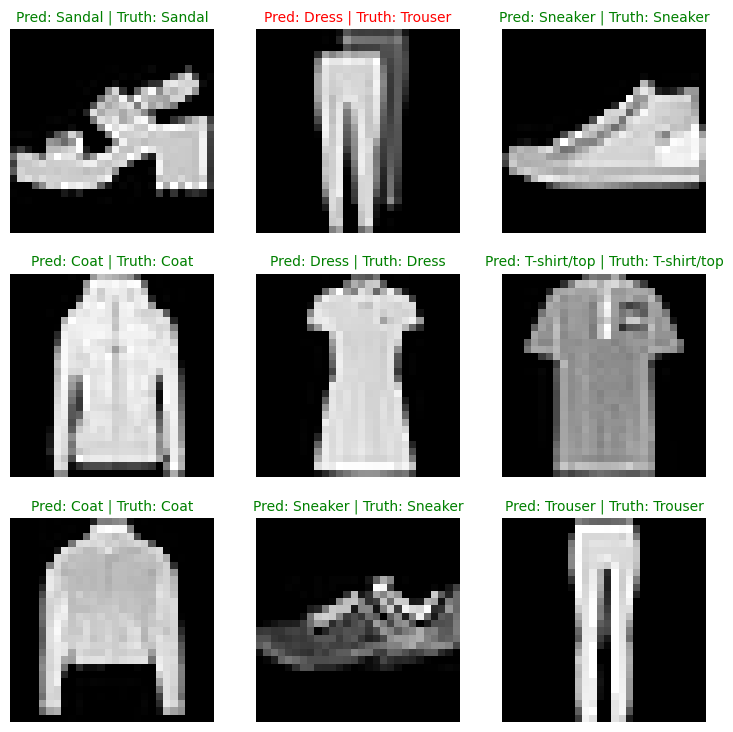

In [82]:
# 1. 도화지 설정
plt.figure(figsize=(9,9))   # 전체 그림의 크기가 9x9 인치
nrows = 3
ncols = 3

for i, sample in enumerate(test_samples):
    # 2. 서브플롯 생성
    plt.subplot(nrows, ncols, i+1)
    
    # 3. 이미지 출력
    # sample.squeeze() 통해 [1, 28, 28] 차원을 [28, 28]로 줄여 2D 이미지로 만듬
    plt.imshow(sample.squeeze(), cmap="gray")
    
    # 4. 예측값과 정답 가져오기
    # 숫자로 된 인덱스(8~9)를 class_names를 이용해 실제 이름으로 변경
    pred_label = class_names[pred_classes[i]]   # 모델이 예측한 이름
    truth_label = class_names[test_labels[i]]  # 실제 이미지 이름
    
    # 5. 제목 텍스트 생성
    title_text = f"Pred: {pred_label} | Truth: {truth_label}"
    
    # 6. 결과에 따른 색상 변경
    # 예측과 정답 같으면 초록(g), 다르면 빨강(r)으로 제목 글자색 변경
    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, c="g")
    else:
      plt.title(title_text, fontsize=10, c="r")
      
    # 7. 축 제거
    plt.axis(False); # 이미지 옆에 눈굼이 나오지 않게 설정


# 10 ) 더 자세한 예측 평가를 위한 혼동 행렬 만들기

- 혼동 행렬 (Confusion Matrix) <br>
-분류 문제에서 사용할 수 있는 평가 지표<br>
-분류 모델이 예측값과 실제 정답 사이에서 어느 부분에서 혼란을 느껴 실수를 저질렀는지 보여줌 

- 혼동 행렬 생성
1. 훈련된 모델 model_2 이용해 예측 수행
2. torchmetrics.ConfusionMatrix를 사용해 혼동 행렬 데이터 생성
3. mlxtend.plotting.plot_confusion_matrix()를 사용해 생성된 행렬을 그래프로 시각화

In [50]:
from tqdm.auto import tqdm  # 진행 표시줄 

# 1. 예측값 저장할 빈 리스트 생성
y_preds =[]
model_2.eval()   # 모델 평가 모드로 설정

with torch.inference_mode(): # 기울기 계산 비활성화해 속도 향상 및 메모리 절약
    # 테스트 데이터로더를 반복해 예측 수행
    for X,y in tqdm(test_dataloader, desc="Making predictions"):
        
        X, y = X.to(device), y.to(device)
        
        # 1. 순전파 : logit 계산
        y_logit = model_2(X)
        
        # 2. logit -> 확률(Softmax) -> 예측 레이블(Argmax) 변환
        # dim=1인 이유 : 데이터가 [Batch_size, Class_count] 형태이므로 1번 차원(클래스들)에서 최대값 사용
        y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
        
        # 3. 평가를 위해 예측값을 CPU로 옮겨 리스트에 저장
        y_preds.append(y_pred.cpu())

# 2. 리스트애ㅔ 담긴 배치 단위 텐서들을 하나의 커다란 텐서로 합침    
y_pred_tensor = torch.cat(y_preds)    

Making predictions: 100%|██████████| 313/313 [00:01<00:00, 189.68it/s]


In [51]:
import mlxtend 
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 # should be version 0.19.0 or higher

0.23.4


1. num_classes=len(class_names)로 우리가 다루는 클래스의 개수를 설정하여 <br>
-> torchmetrics.ConfusionMatrix 인스턴스를 생성

2. 모델의 예측값(preds=y_pred_tensor)과 실제 정답(target=test_data.targets)을 전달 <br>
-> (텐서 형태의) 혼동 행렬 생성

- mlxtend.plotting의 plot_confusion_matrix() 함수 : 혼동 행렬 그래프로 그림

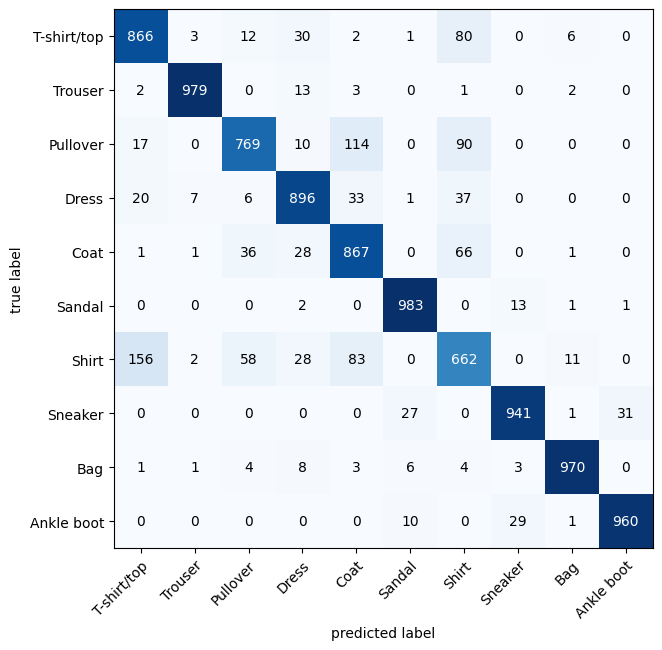

In [52]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. 혼동 행렬 인스턴스를 설정하고 예측값과 실제 정답(targets)을 비교
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. 혼동 행렬을 그래프로 그림
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib은 NumPy 배열로 작업하는 것을 선호
    class_names=class_names, # turn the row and column labels into class names
    figsize=(10, 7)     # 그래프의 가로, 세로 크기를 설정
);

-> 진한 사각형들이 대각선에 집중되어 있음 -> 모델의 성능이 좋은 편

# 11 ) 가장 성능이 좋은 모델 저장 및 불러오기
- torch.save : pytorch 모델이나 모델의 state_dict() (상태 사전)를 저장하는 함수
- torch.load : 저장된 Pytorch 객체를 불러오는 함수
- torch.nn.Module.load_state_dict(): 저장된 state_dict()를 이미 생성된 모델 인스턴스에 덮어씌우는 함수
- loaded_state_dict : 읽어온 숫자 값들을 만든 모델에 대입

1. model_2의 state_dict() 저장한 다음, 다시 불러와서 평가해 저장과 로드가 올바르게 수행되었는지 확인하기

*state_dict : 각 계층의 이름이 key, 해당 계층의 가중치나 편향인 텐서가 value <br>
-nn.Linear나 nn.Conv2d처럼 학습을 통해 값이 변하는 매개변수들이 포함됨 <br>

* pathlib : 경로를 단순 문자열이 아닌 객체로 다룰 수 있도록 하는 모듈


In [83]:
from pathlib import Path

MODEL_PATH = Path("models") # "models" 이름의 폴더 경로 설정
MODEL_PATH.mkdir(parents=True,  # 상위 폴더가 없으면 상위 폴더까지 생성
                 exist_ok=True) # 폴더가 이미 있어도 에러 x

MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"   # 저장할 파일 이름
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME   # 폴더 경로와 파일 이름을 합침

print(f"saving model to : {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(),    # 모델의 학습된 파라미터만 추출해서 파일로 저장
            f=MODEL_SAVE_PATH)  

saving model to : models\03_pytorch_computer_vision_model_2.pth


-> 이제 저장된 모델의 state_dict()가 있으므로, load_state_dict()와 torch.load()를 조합하여 모델을 다시 불러올 수 있음

- 우리는 load_state_dict() 사용하기 때문에 저장된 모델의 state_dict()와 동일한 입력 파라미터를 가진 FashionMNISTModelV2()의 새 인스턴스를 먼저 생성해야함

In [85]:
# 저장된 state_dict()와 같은 클래스인 FashionMNISTModelV2의 새 인스턴스 생성
loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                     hidden_units=10,
                                     output_shape=10)

loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# model GPU로 보내기 - 학습할 때 사용했던 장치와 동일한 곳으로 보내야 평가과정에서 오류X
loaded_model_2 = loaded_model_2.to(device)

In [87]:
# 불러온 model 평가
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    accuracy_fn=accuracy_fn
)

loaded_model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32201331853866577,
 'model_acc': 88.33865814696486}

In [88]:
# model_2와 비교
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32201334834098816,
 'model_acc': 88.33865814696486}

- torch.isclose() <br>
-atol (절대 허용 오차) 및 rtol (상대 허용 오차) 파라미터를 통해 근접도(허용 범위)를 전달함으로써 두 텐서가 얼마나 가까운지 확인 가능 <br>
-우리 모델의 결과값들이 충분히 가깝다면, torch.isclose()의 출력값은 True

In [92]:
torch.isclose(torch.tensor(model_2_results["model_loss"]),
              torch.tensor(loaded_model_2_results["model_loss"]),
              atol=1e-08 ,   # 절대 허용 오차
              rtol=0.0001   # 상대 허용 오차 
)

tensor(True)